# Exercise: generic list

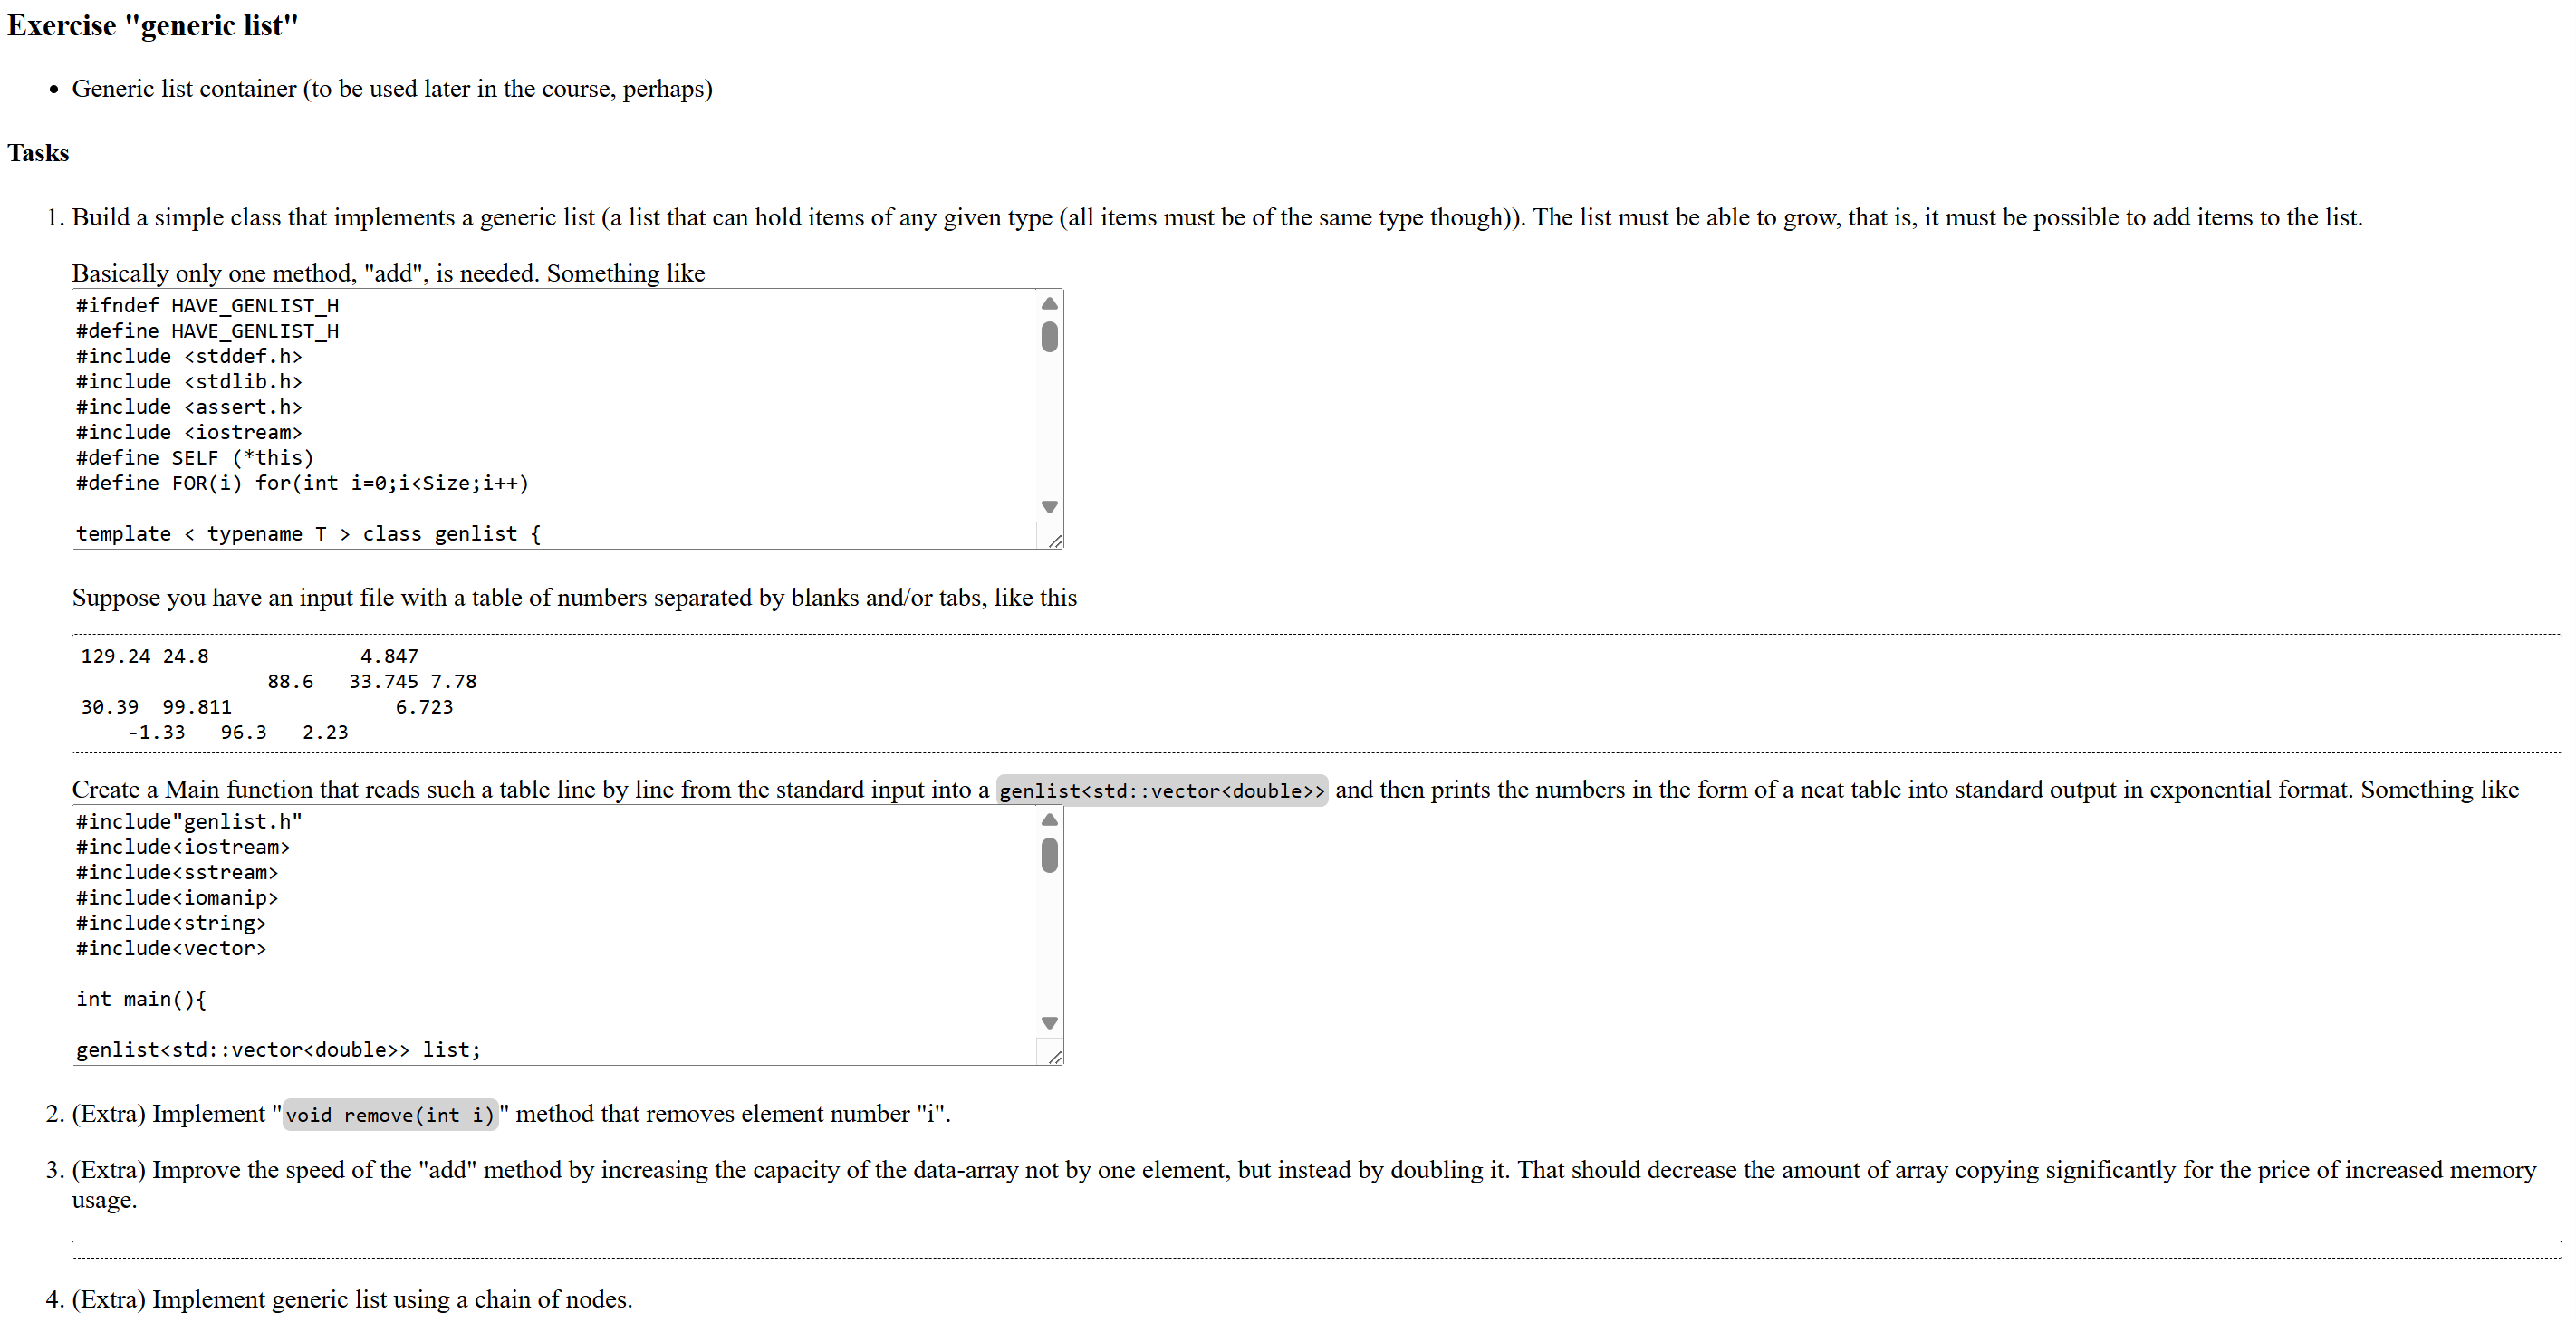

In this exercise a simple generic list container was implemented in C++. The class is templated, so it can store elements of any type, as long as all elements in one list have the same type.

The list supports:

- adding elements with `add`,
- removing elements with `remove`,
- indexing with `operator[]`,
- automatic growth of the internal array,
- capacity doubling to avoid reallocating the array at every insertion.

The implementation is placed in the header file `genlist.h`, because C++ templates must normally have their full implementation visible when they are used.

In [1]:
from pathlib import Path

Path("genlist.h").write_text(r'''
#ifndef HAVE_GENLIST_H
#define HAVE_GENLIST_H

#include <algorithm>
#include <cassert>
#include <stdexcept>
#include <utility>

template <typename T>
class genlist {
private:
    int sz;
    int cap;
    T* data;

    void grow_to(int newcap) {
        if (newcap <= cap) return;

        T* newdata = new T[newcap];

        for (int i = 0; i < sz; ++i) {
            newdata[i] = std::move(data[i]);
        }

        delete[] data;
        data = newdata;
        cap = newcap;
    }

    void ensure_capacity(int wanted) {
        if (wanted <= cap) return;

        int newcap = (cap == 0) ? 1 : cap;
        while (newcap < wanted) {
            newcap *= 2;
        }

        grow_to(newcap);
    }

public:
    genlist()
        : sz(0), cap(0), data(nullptr) {}

    explicit genlist(int capacity)
        : sz(0), cap(capacity), data(capacity > 0 ? new T[capacity] : nullptr) {}

    ~genlist() {
        delete[] data;
    }

    genlist(const genlist& other)
        : sz(other.sz), cap(other.cap), data(other.cap > 0 ? new T[other.cap] : nullptr) {
        for (int i = 0; i < sz; ++i) {
            data[i] = other.data[i];
        }
    }

    genlist(genlist&& other) noexcept
        : sz(other.sz), cap(other.cap), data(other.data) {
        other.sz = 0;
        other.cap = 0;
        other.data = nullptr;
    }

    genlist& operator=(const genlist& other) {
        if (this == &other) return *this;

        T* newdata = other.cap > 0 ? new T[other.cap] : nullptr;

        for (int i = 0; i < other.sz; ++i) {
            newdata[i] = other.data[i];
        }

        delete[] data;

        data = newdata;
        sz = other.sz;
        cap = other.cap;

        return *this;
    }

    genlist& operator=(genlist&& other) noexcept {
        if (this == &other) return *this;

        delete[] data;

        sz = other.sz;
        cap = other.cap;
        data = other.data;

        other.sz = 0;
        other.cap = 0;
        other.data = nullptr;

        return *this;
    }

    int size() const {
        return sz;
    }

    int capacity() const {
        return cap;
    }

    void add(const T& value) {
        ensure_capacity(sz + 1);
        data[sz] = value;
        ++sz;
    }

    void add(T&& value) {
        ensure_capacity(sz + 1);
        data[sz] = std::move(value);
        ++sz;
    }

    void remove(int i) {
        if (i < 0 || i >= sz) {
            throw std::out_of_range("genlist::remove index out of range");
        }

        for (int j = i; j < sz - 1; ++j) {
            data[j] = std::move(data[j + 1]);
        }

        --sz;
    }

    T& operator[](int i) {
        assert(i >= 0 && i < sz);
        return data[i];
    }

    const T& operator[](int i) const {
        assert(i >= 0 && i < sz);
        return data[i];
    }
};

#endif
''')

print("Wrote genlist.h")

Wrote genlist.h


In [2]:
from pathlib import Path

Path("main.cc").write_text(r'''
#include "genlist.h"

#include <cmath>
#include <iomanip>
#include <iostream>
#include <sstream>
#include <string>
#include <vector>

int main() {
    genlist<std::vector<double>> table;

    std::string line;

    while (std::getline(std::cin, line)) {
        std::stringstream ss(line);
        std::vector<double> row;

        double value;
        while (ss >> value) {
            row.push_back(value);
        }

        if (!row.empty()) {
            table.add(row);
        }
    }

    std::cout << "Exercise generic list\n";
    std::cout << "=====================\n\n";

    std::cout << "Number of rows read = " << table.size() << "\n";
    std::cout << "Internal capacity   = " << table.capacity() << "\n\n";

    std::cout << "Table printed in scientific format:\n";
    std::cout << "-----------------------------------\n";

    std::cout << std::scientific << std::setprecision(6);

    for (int i = 0; i < table.size(); ++i) {
        for (double x : table[i]) {
            std::cout << std::setw(16) << x;
        }
        std::cout << "\n";
    }

    std::cout << "\nTesting add and remove with genlist<int>:\n";
    std::cout << "----------------------------------------\n";

    genlist<int> test;

    for (int i = 0; i < 10; ++i) {
        test.add(i);
    }

    std::cout << "Initial list: ";
    for (int i = 0; i < test.size(); ++i) {
        std::cout << test[i] << " ";
    }
    std::cout << "\n";

    test.remove(4);

    std::cout << "After remove(4): ";
    for (int i = 0; i < test.size(); ++i) {
        std::cout << test[i] << " ";
    }
    std::cout << "\n";

    std::cout << "Final size     = " << test.size() << "\n";
    std::cout << "Final capacity = " << test.capacity() << "\n";

    return 0;
}
''')

Path("input.txt").write_text(r'''
129.24 24.8 4.847
88.6 33.745 7.78
30.39 99.811 6.723
-1.33 96.3 2.23
'''.strip() + "\n")

Path("Makefile").write_text(r'''
CXX = g++
CXXFLAGS = -std=c++23 -O2 -Wall -Wextra

Out_genlist.txt: genlist input.txt
	./genlist < input.txt > Out_genlist.txt

genlist: main.cc genlist.h
	$(CXX) $(CXXFLAGS) main.cc -o genlist

clean:
	rm -f genlist Out_genlist.txt
''')

print("Wrote main.cc")
print("Wrote input.txt")
print("Wrote Makefile")

Wrote main.cc
Wrote input.txt
Wrote Makefile


In [3]:
import subprocess
from pathlib import Path

r = subprocess.run(
    ["make", "Out_genlist.txt"],
    text=True,
    capture_output=True
)

print("Compiler/make output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    print("Program output:")
    print(Path("Out_genlist.txt").read_text())
else:
    print("Compilation failed.")

Compiler/make output:
g++ -std=c++23 -O2 -Wall -Wextra main.cc -o genlist
./genlist < input.txt > Out_genlist.txt


Program output:
Exercise generic list

Number of rows read = 4
Internal capacity   = 4

Table printed in scientific format:
-----------------------------------
    1.292400e+02    2.480000e+01    4.847000e+00
    8.860000e+01    3.374500e+01    7.780000e+00
    3.039000e+01    9.981100e+01    6.723000e+00
   -1.330000e+00    9.630000e+01    2.230000e+00

Testing add and remove with genlist<int>:
----------------------------------------
Initial list: 0 1 2 3 4 5 6 7 8 9 
After remove(4): 0 1 2 3 5 6 7 8 9 
Final size     = 9
Final capacity = 16



## Exercise "generic list" conclusion

A simple generic list container was implemented in C++ using a template class. The list stores elements in a dynamically allocated array and can therefore hold any type, for example `int`, `double`, or `std::vector<double>`.

The `add` method was implemented with capacity doubling. This means that the internal array is not reallocated for every new element, but instead grows by factors of two. This makes repeated insertions much more efficient than increasing the capacity by only one element at a time.

The extra `remove(int i)` method was also implemented. It removes the selected element by shifting all later elements one position to the left.

The program reads a table of numbers from standard input into a `genlist<std::vector<double>>` and prints the table in scientific notation. Additional tests with `genlist<int>` show that both `add` and `remove` work as expected.